### 6/23/26 just checking to see if the output is normal

## Background

The goal of this project is to validate diagnostics for calculating numerical mixing through use of a water mass transformation framework. This suspected relationship is outlined in Appendix A of [Global observational estimates of thermohaline transformations by interior ocean mixing](https://doi.org/10.1175/JPO-D-25-0265.1) (Castro et al., 2026). 

Note that a general equation for the diascalar material transformation for a process $P$ for a water mass $\mathcal{M}$ defined to be all tracer $\lambda$ values greater than $\tilde \lambda$. The convergence of a flux $\mathcal{F} = \nabla \cdot \mathbf{F}$.

$$
    \mathcal{G}_{\ge}^{\text{(P)}} = \int_{\mathcal{A_R}(\tilde\lambda, t)} - \frac{\rho}{\vert \nabla \lambda \vert} \mathcal{F} \, \text{d}S = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} -\rho \mathcal{F} \,\text{d} V\right] \tag{1}
$$

And the subsequent diascalar material transformation demonstrating a relationship between mixing calculated as a convergence of a diffusive flux and mixing calculated as tracer variance decay is

*tbh, idk if this is the equation they use, but this is the equation I derived in my advancement proposal*
$$
\begin{equation}
\mathcal{G}^{\text{(phy)}} = \underbrace{\int_{\mathcal{A_R}(\tilde \lambda, t)} - \frac{\rho}{\vert \nabla \lambda \vert} \left(- \nabla \cdot \left(-\kappa_{phy} \nabla \lambda\right)\right) \, \text{d}S}_{\text{mixing as conv. of diff. flux}} = \underbrace{-\frac{1}{2} \frac{\partial^2}{\partial \tilde\lambda^2}\left[ \int_{\Omega(\tilde\lambda ,t)} \rho \left( 2 \kappa_{phy} \vert\vert \nabla \lambda \vert\vert^2\right) \, \text{d}V\right]}_{\text{mixing as var. decay}} 
\tag{2}
\end{equation}
$$ 


While Castro et al. describes a relationship between the convergence of a diffusive tracer flux and tracer variance decay for *phyiscal* mixing, we propose to look at *numerical* mixing through a similar framework. This relationship would look very similar to Equation 2, but our we would instead be solving for the term $\mathcal{G}^{\text{(num)}}$ and the diffusivities would be $\kappa_{num}$ rather than $\kappa_{phy}$. 

### Mixing as convergence of a diffusive flux
We quickly run into a problem, which is that $\kappa_{num}$ is unknown when calculating the nuemrical mixing as the convergence of a diffusive flux. Recall that $\kappa_{phy}$ comes from a prescribed background diffusivity. In which case, we need a different way to calculate $\mathcal{G}^{\text{(num)}}$. We propose to do so using the WMT budget residual.

$$
\begin{align}
    \partial_t{\mathcal{M}} &= \Psi + \mathcal{S} + \mathcal{G^{\text{(BF)}}} + \mathcal{G^{\text{(phy)}}} + \mathcal{G^{\text{(num)}}} \\
    \implies \mathcal{G^{\text{(num)}}} & = \partial_t{\mathcal{M}} - \Psi + \mathcal{S} - \mathcal{G^{\text{(BF)}}} - \mathcal{G^{\text{(phy)}}}
    \tag{3}
\end{align} 
$$

### Mixing as tracer variance decay
We *can*, however, calculate a $\kappa_{num}$ when thinking about numerical mixing through the perspective of tracer variance decay, if we use the Discrete Varaince Decay (DVD) algorithm.
Let 
$$
\begin{equation}
	\chi^{\text{(num)}} = \underbrace{\frac{A\{\left(\lambda_i^n\right)^2\} -\left[A\{\lambda_i^n\}\right]^2}{\Delta t}}_{\text{DVD}} = \underbrace{-2 \kappa_{num}\frac{\left(\lambda_i^n - \lambda_{i-1}^n\right)^2}{(\Delta x)^2}}_{\substack{\text{discretized mixing}\\\text{as variance decay}}} \approx \underbrace{-2 \kappa_{num}\left(\frac{\partial \lambda}{\partial x}\right)^2}_{\substack{\text{continuous mixing}\\\text{as variance decay}}} \tag{4}
\end{equation}
$$

The $\kappa_{num}$ arises out of the mathematical manipulation of the advection operator to get the rest of thet algorithm.
$$
    \kappa_{num} = u\Delta x \left(1 - \frac{u \Delta t}{\Delta x}\right) \tag{5}
$$

The $\chi^{\text{(num)}}$ term is a tendency that can now be written in the WMT framework as 
$$
    \mathcal{G}^{\text{(num)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(num)}} \, \text{d}V\right] \tag{6}
$$

### WMT relationship of numerical mixing as a budget residual and as tracer variance decay.
The following relationship (in terms of the WMT framework) between Equations 2 and 3 then emerges.

$$
\begin{equation}
    \mathcal{G}^{\text{(num)}} = \partial_t{\mathcal{M}} - \Psi + \mathcal{S} - \mathcal{G^{\text{(BF)}}} - \mathcal{G^{\text{(phy)}}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi \, \text{d}V\right] \tag{7}
\end{equation}
$$

*do NOT trust the signs in this argument, it depends on the direction you're integrating, and I'm sure I have several sign errors rn*

In [1]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mosaic
from xgcm import Grid

### Open files & visualize raw data

In [2]:
# filepath = '/pscratch/sd/k/kuyeda/WMT_DVD/bichan/10km/'
# ds_output = xr.open_dataset(filepath + '10km_channel_output.nc')
# ds_dvd = xr.open_dataset(filepath + 'analysis_members/10km_channel_DVD.0001-01-01.nc')
# ds_wmt = xr.open_dataset(filepath + 'analysis_members/10km_channel_WMT_Monthly.0001-01-01.nc')
# mesh = xr.open_dataset(filepath + '10km_channel_init.nc')
# descriptor = mosaic.Descriptor(mesh, use_latlon=False)

In [31]:
filepath = '/pscratch/sd/k/kuyeda/WMT_DVD/bichan/10km/'
ds_output = xr.open_dataset(filepath + '10km_channel_output.nc')
ds_dvd = xr.open_dataset(filepath + 'analysis_members/10km_channel_DVD.0001-01-01.nc')
mesh = xr.open_dataset(filepath + '10km_channel_init.nc')
descriptor = mosaic.Descriptor(mesh, use_latlon=False)

# format ds_dvd so that it includes a time=0 index (otherwise missing first time step)
ds_dvd = xr.concat([ds_dvd.isel(Time=0), ds_dvd],dim='Time')
ds_dvd["xtime"][0]= np.array(b"0001-01-01_00:00:00", dtype="|S64")

ds_dvd['xtime'] = ds_dvd.xtime.assign_attrs(description='time=0 data is copy of time=1')

# interpolate the DVD vertical physical mixing onto nVertLevels
grid_dvd = Grid(ds_dvd, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                        periodic = False, 
                        autoparse_metadata=False)
ds_dvd['chiPhyVerTemp_center'] = grid_dvd.interp(ds_dvd.chiPhyVerTemp, 'Z' ,boundary = 'extend')
ds_dvd['chiPhyVerSalt_center'] = grid_dvd.interp(ds_dvd.chiPhyVerSalt, 'Z', boundary = 'extend')

# set time index
time_idx = 250

In [32]:
for i in ds_output.data_vars:
    if 'Mix' in i:
        print(i)

temperatureVertMixTendency
salinityVertMixTendency
temperatureHorMixTendency
salinityHorMixTendency


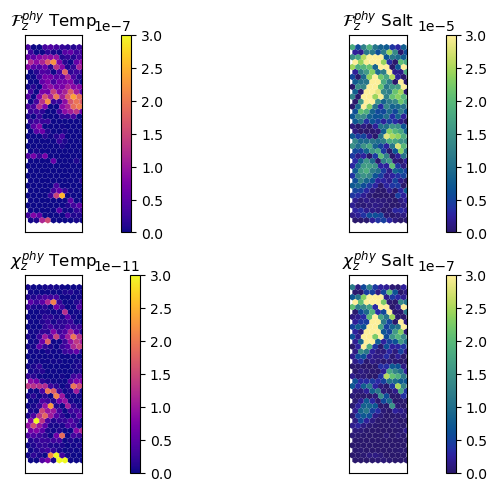

In [33]:
# comparison of mixing
fig,ax = plt.subplots(nrows=2, ncols = 2, constrained_layout=True)

# calculated as convergence of diffusive flux
a = mosaic.polypcolor(ax[0,0],descriptor, ds_output.temperatureVertMixTendency.isel(Time=time_idx, nVertLevels=0), cmap='plasma',vmin=0, vmax=3e-7)
b = mosaic.polypcolor(ax[0,1],descriptor, ds_output.salinityVertMixTendency.isel(Time=time_idx, nVertLevels=0),cmap='cmo.haline',vmin=0,vmax=3e-5)
ax[0,0].set_title(r'$\mathcal{F}^{phy}_{z}$ Temp')
ax[0,1].set_title(r'$\mathcal{F}^{phy}_{z}$ Salt')

# calculated as tracer variance decay
c = mosaic.polypcolor(ax[1,0],descriptor, ds_dvd.chiPhyVerTemp_center.isel(Time=time_idx, nVertLevels=0), cmap='plasma',vmin=0, vmax = 3e-11)
d = mosaic.polypcolor(ax[1,1],descriptor, ds_dvd.chiPhyVerSalt_center.isel(Time=time_idx, nVertLevels=0), cmap='cmo.haline',vmin=0,vmax=3e-7)
ax[1,0].set_title(r'$\chi_z^{phy}$ Temp')
ax[1,1].set_title(r'$\chi_z^{phy}$ Salt')

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].set_aspect(1.0)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

fig.colorbar(a, ax = ax[0,0])
fig.colorbar(b, ax = ax[0,1])
fig.colorbar(c, ax = ax[1,0])
fig.colorbar(d, ax = ax[1,1])

## Explanation of data


|Dataset Name|Description|
|--| --|
|`ds_output` | standard output variables (T, S, velo)|
|`ds_dvd` | $\chi^{\text{(phy)}}$ and $\chi^{\text{(num)}}$ from DVD alg.|
|`ds_output` | $\mathcal{F} \,; [^\circ C s^{-1}]$ ; conv. of diff. flux |
|`mesh` | grid variables (cellsOnEdge, etc) |

>- Simulations were run with a linear equation of state such that $\rho_0 = 1027 \, kg/m^3$ $\leftarrow$ CHECK THIS 
>- No prescribed horizontal mixing $\kappa_{phy,x} = 0$, so we expect `TracerHorMixTendency` to be 0 (`ds_output` dataset).
>- Vertical mixing is prescribed using KPP where the background diffusivity is $\kappa_{phy,z} = 10e-5 \, m^2s^{-1}$.
>- The background viscosity is set to $\nu = 10e-4 \, m^2 s^{-1}$.
>- Only wind stress forcing is prescribed.
>- The `TracerSurfaceFluxTendency` in the `ds_output` dataset is 0 because we do not have any boundary forcing that would introduce tracers at the surface.

The $\mathcal{F}$ and $\chi$ outputs require that we calculate $\mathcal{G}^{\text{(phy)}}$ and $\mathcal{G}^{\text{(num)}}$ offline. The following math is necessary.

*Recall that in order to calculate the residual, we need to directly calculate all other terms in the budget*

We need to plug in $\mathcal{F}$ (`TracerVertMixTendency`) into Equation 1.
$$
\begin{equation}
    \mathcal{G}_{\ge}^{\text{(phy)}} = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} -\rho \mathcal{F} \,\text{d} V\right] \tag{1}
\end{equation}
$$

We need to plug in $\chi^{\text{(num)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}^{\text{(num)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(num)}} \, \text{d}V\right] \tag{6}
\end{equation}
$$

To compare physical mixing calculations, we plug in $\chi^{\text{(phy)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}^{\text{(phy)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(phy)}} \, \text{d}V\right] \tag{8}
\end{equation}
$$

## Calculate $\mathcal{G}^{\text{(phy)}}$ from convergence of a diffusive flux

The discretized version of Equation 1 is

$$
\begin{align}
    \mathcal{G}_{\ge}^{\text{(phy)}} = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} -\rho \mathcal{F} \,\text{d} V\right] &= \frac{\partial}{\partial \tilde\lambda} \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]  \\
    &=  \left(\left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i+1}} -  \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i}}\right) \times \frac{1}{\tilde\lambda_{i} - \tilde\lambda_{i+1}}
\end{align}
$$
for $(x,y,z) \in \{\lambda \ge \tilde\lambda^\prime\}$.

*Note that we take are looking at $\lambda_i - \lambda_{i+1}$ rather than the other way around. This is because we defined $\mathcal{M}_\ge$ to account for all salinities **greater** than the threshold lambda $\tilde\lambda$. So we are looking from the saltier value to a fresher value (decreasing $\lambda$), rather than a traditional increase.*

### Step by step explanation
1. Take the mass tendency (why we multiply by $\rho$) weighted by volume $\left( \text{d}V \right)$ for every grid cell. This is the *integrand*.
2. Regrid from z-coordinates to tracer coordinates
3. For every tracer class, take the sum of the integrand over all grid cells in that tracer class.
4. Calculate the discretized change in integrand (tendency) over change in tracer class. 

In [ ]:
# write function to calculate G_phy
def calculate_G_F_phy(rho_0, mesh, ds_output):
    # calculate the integrand
    dV = (mesh.areaCell * mesh.layerThickness).isel(Time=0)
    integrand = (ds_output.salinityVertMixTendency * rho_0 * dV)
    
    # update ds_output dataset to include integrand dataarray
    ds_output['integrand'] = integrand

    # Remap to salinity coordinates
    # to conservatively remap from xgcm 

In [34]:
## SOMETHING IS WRONG I JUST DON'T KNOW WHAT YET

In [35]:
# calculate the integrand
rho_0 = 1026 # kg/m^3
dV = (mesh.areaCell * mesh.layerThickness).isel(Time=0)

integrand = (ds_output.salinityVertMixTendency * rho_0 * dV)

# update ds_output dataset to include integrand dataarray
ds_output['integrand'] = integrand

### Remapping into salinity coordinates
We need to remap from vertical coordinates `nVertLevels` to salinity coordinates `salinity`.

To perform a [conservative remap with `xgcm`](https://xgcm.readthedocs.io/en/latest/transform/#linear-transformation), datavariables must originally sit on cell centers. We supply cell edges to calculate the remap. The datavariable will then ultimately end up on the cell center. 

So we must 
1. Ensure our datavariable sits on `salinity` to begin with.
2. Supply the `outer` `P1` coordinate for the transformation. 
3. Transform such that the datavariable now sits on `salinity` and not `nVertLevels`.

In [36]:
# set up salinity data to be target coords
# not for this set up, but good practice in case there's topography
# fill the bottom cell with the same value as the one above it (so it is no longer a nan)
ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

# crudely calculate target salinity coordinates (salinity_P1)
# interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                        periodic = False, 
                        autoparse_metadata=False)

ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', boundary = 'extend')

# +2 to ensure that the upper and lower bins have a Gphy = 0
lower_bound = ds_output.salinity_P1.min() - 2
upper_bound = ds_output.salinity_P1.max() + 2
target_coords_P1 = np.arange(lower_bound,upper_bound,1)
dlambda = target_coords_P1[1] - target_coords_P1[0]

# transform integrand (currently sitting on center nVertLevels) to salinity_P1 coordinates
ds_output_salinity_mix_tendencyZ_transformed = grid_nVertLevels.transform(ds_output.integrand, # data we want to transform (on cell centers)
                                                                       'Z', # axis of transformation
                                                                       target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
                                                                       method = 'conservative', # method
                                                                       target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned

ds_output_salinity_mix_tendencyZ_transformed_ds = ds_output_salinity_mix_tendencyZ_transformed.to_dataset(name='integrand_transformed')

# the transform remapped the datavariable to the CENTER of the cell 
# rename the salinity_P1 coords to salinity
ds_output_salinity_mix_tendencyZ_transformed_ds = ds_output_salinity_mix_tendencyZ_transformed_ds.rename({'salinity_P1' : 'salinity'})

# add back the salinity_P1 coordinates
ds_output_salinity_mix_tendencyZ_transformed_ds = ds_output_salinity_mix_tendencyZ_transformed_ds.assign_coords({'salinity_P1' : target_coords_P1})

# after transforming, our datavariable sits on salinity_P1, but we want to maintain salinity as a coordinate
# interpolate the salinity_P1 values to get salinity values
# we know that target_coords_P1 is evenly spaced, so taking an average is easy
target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2

In [37]:
# then calculate the derivative d_integrand
# create an array
G_phy = []

# taking the difference remaps from salinity coords to salinity_P1 coords
for i in range(0,len(target_coords_P1) - 2):
    d_tracerMassFlux = ds_output_salinity_mix_tendencyZ_transformed_ds.integrand_transformed[:,:,i] - ds_output_salinity_mix_tendencyZ_transformed_ds.integrand_transformed[:,:,i+1]
    d_tracerMassFlux_dlambda = d_tracerMassFlux / dlambda
    G_phy.append(d_tracerMassFlux_dlambda)

# this eliminates the first and last entry in salinity_P1 coords
salinity_P1_trimmed = target_coords_P1[1:-1]
G_phy_ds = (xr.concat(G_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')

# add back salinity_coords
# after transforming, our datavariable sits on salinity_P1, but we want to maintain salinity as a coordinate
# interpolate the salinity_P1 values to get salinity values
# we know that target_coords_P1 is evenly spaced, so taking an average is easy
target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
salinity_trimmed = target_coords[1:-1]

G_phy_ds = G_phy_ds.assign_coords({'salinity' : salinity_trimmed})

## Tentative $\mathcal{G}^{\text{(phy)}}_\mathcal{F}$ plots 

6/25/26

(see work in Commit `f8eaea0` in [github](https://github.com/kailauyeda/WMT_DVD/commit/f8eaea02d11ecfcccf842af883d2e0cda0d375a4) for corresponding figures)
>- We have define our water mass to be all waters with $\lambda \ge \tilde\lambda$
>- This means we should integrate (cumsum) from our greatest salinity values to our lowest.
>- By the time we reach $\tilde\lambda = \tilde\lambda_{freshest}$, then the entire water column will be accounted for.
>- $\mathcal{M}_{\ge}$ increases in size when "its mass transfports are net convergent and therefore increase the size of $\mathcal{M}_\ge$ defined to have salinity values greater than the threshold $\tilde\lambda$."
>>- This is based on the definition of WMT from Drake et al., 2025.
>>- This would mean that **positive** values of $\mathcal{G}^{\text{(phy)}}$ **increase salinity** (fresh water gets mixed into a saltier density class $\mathcal{M}_\ge$)
>>- And **negative** values of $\mathcal{G}^{\text{(phy)}}$ **decrease salinity** (salty water gets mixed OUT of $\mathcal{M}_\ge$)
>- Looking at the $\mathcal{G}^{\text{(phy)}}$ cumsum graph (left):
>- We see that salty density classes $\lambda \gtrsim 35 \, g/kg \times 10e-3$ are getting fresher $\mathcal{G}^{\text{(phy)}} < 0$
>- We see that fresher density classes $\lambda \lesssim 35 \, g/kg \times 10e-3$ are getting saltier $\mathcal{G}^{\text{(phy)}} > 0$
>>- This suggests mixing across all density classes?
>- I am less certain how to interpret the others $\mathcal{G}^{\text{(phy)}}$ figure. It looks like the most mixing is occurring at that $\lambda = 35$ interface ($\max \mathcal{G}^{\text{(phy)}}$)

----
6/26/26

Interpretation after a more scientifically sound way of remapping (average over time last)
>- Made this calculation more scientifically sound, but idk what these figures mean anymore. 
>- Genuinely, I don't get this for a couple reasons.
1. How is it possible that for nearly all salinity classes, $\mathcal{G}^{\text{(phy)}}_\mathcal{F}$ is greater than 0?
>- I'm pretty sure there's a sign error because I calculated the difference of the integrand by doing `i` - `i+1` (since we define $\mathcal{M}_\ge$ for salinity values *greater than* $\tilde\lambda$. But I calculate $\Delta \lambda$ using `i+1` - `i` so that $\Delta \lambda > 0$.
>- Physically, I have no clue what this means. All water is getting saltier? Idk how water can mix and only get saltier, shouldn't the freshwater cause the salty water to get fresher? Why don't we see this?
>- Why is the cumulative sum almost nearly monotonically increasing? Again, wouldn't this point to more transformation in only one direction?

2. Does this mean that to get the budget to close numerical mixing is negative/acts in the opposite direction? That just doesn't make any sense to me.
>- I just find it very hard to believe that physical mixing only acts in one direction, and nuemrical mixing acts in the other?

3. But I genuinely thought that all my calculations up until this point have been much more careful with remapping to cell centers and averaging after the remap? 


In [38]:
# cumsum from bottom (lowest salinity class) to top (highest salinity class)
# we need to perform a reverse cumsum because our water mass M is defined to be all values GREATER Than threshold lambda
# reduce G_phy_ds along several dimensions
G_phy = G_phy_ds.G_F_phy.isel(Time = time_idx).sum(dim = 'nCells')

rev_G_phy = np.flipud(G_phy)
cumsum_rev_G_phy = np.cumsum(rev_G_phy)
# reverse back to match highest salinity value to lowest cumsum value
cumsum_G_phy = np.flipud(cumsum_rev_G_phy)

In [39]:
### why does this look so different from the previously created figures? Idk how to interpret this at ALL
### why is the cumsum increasing so much as we move to lighter and lighter waters...
### why is this happening????

Text(0.5, 0.98, 'Diascalar material transformation  $\\mathcal{G}_\\mathcal{F}^{\\text{(phy)}}$ time_idx = 250')

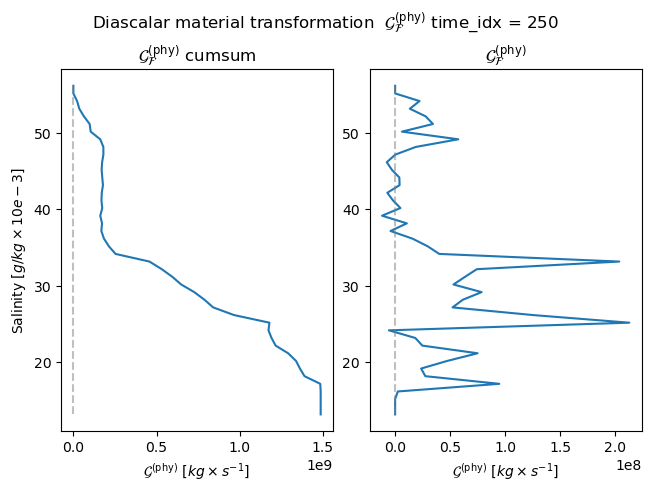

In [40]:
fig, ax = plt.subplots(nrows=1,ncols=2,constrained_layout=True)

ax[0].plot(cumsum_G_phy, G_phy_ds.salinity_P1)
ax[0].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$ cumsum')
ax[1].plot(G_phy, G_phy_ds.salinity_P1)
ax[1].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
ax[0].vlines(0,ymin=G_phy_ds.salinity_P1[0], ymax = G_phy_ds.salinity_P1[-1], color='gray', alpha=0.5,linestyle='dashed')
ax[1].vlines(0,ymin=G_phy_ds.salinity_P1[0], ymax = G_phy_ds.salinity_P1[-1], color='gray', alpha=0.5,linestyle='dashed')

ax[0].set_xlabel(r'$\mathcal{G}^{\text{(phy)}} \,\, \left[kg \times s^{-1}\right]$ ')
ax[0].set_ylabel(r'Salinity $\left[ g/kg \times 10e-3\right]$')

ax[1].set_xlabel(r'$\mathcal{G}^{\text{(phy)}} \,\, \left[kg \times s^{-1}\right]$ ')

fig.suptitle(r'Diascalar material transformation  $\mathcal{G}_\mathcal{F}^{\text{(phy)}}$ time_idx = 250')

In [41]:
# average over time
# cumsum from bottom (lowest salinity class) to top (highest salinity class)
# we need to perform a reverse cumsum because our water mass M is defined to be all values GREATER Than threshold lambda
# reduce G_phy_ds along several dimensions
G_phy = G_phy_ds.G_F_phy.mean(dim='Time').sum(dim = 'nCells')

rev_G_phy = np.flipud(G_phy)
cumsum_rev_G_phy = np.cumsum(rev_G_phy)
# reverse back to match highest salinity value to lowest cumsum value
cumsum_G_phy = np.flipud(cumsum_rev_G_phy)

Text(0.5, 0.98, 'Time-Averaged Diascalar material transformation  $\\mathcal{G}_\\mathcal{F}^{\\text{(phy)}}$')

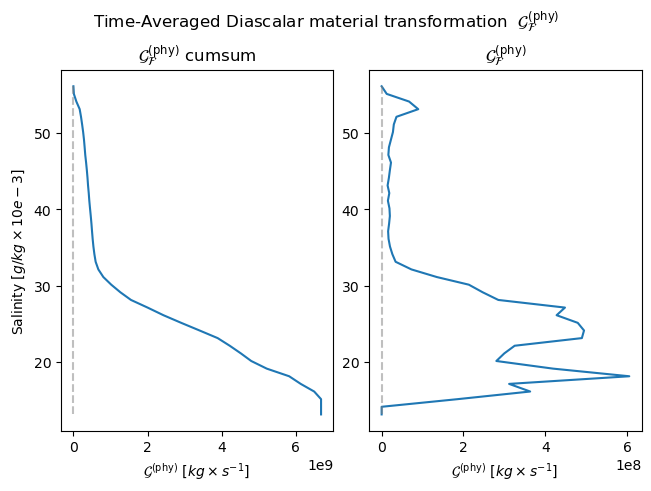

In [42]:
fig, ax = plt.subplots(nrows=1,ncols=2,constrained_layout=True)

ax[0].plot(cumsum_G_phy, G_phy_ds.salinity_P1)
ax[0].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$ cumsum')
ax[1].plot(G_phy, G_phy_ds.salinity_P1)
ax[1].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
ax[0].vlines(0,ymin=G_phy_ds.salinity_P1[0], ymax = G_phy_ds.salinity_P1[-1], color='gray', alpha=0.5,linestyle='dashed')
ax[1].vlines(0,ymin=G_phy_ds.salinity_P1[0], ymax = G_phy_ds.salinity_P1[-1], color='gray', alpha=0.5,linestyle='dashed')

ax[0].set_xlabel(r'$\mathcal{G}^{\text{(phy)}} \,\, \left[kg \times s^{-1}\right]$ ')
ax[0].set_ylabel(r'Salinity $\left[ g/kg \times 10e-3\right]$')

ax[1].set_xlabel(r'$\mathcal{G}^{\text{(phy)}} \,\, \left[kg \times s^{-1}\right]$ ')

fig.suptitle(r'Time-Averaged Diascalar material transformation  $\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')

In [43]:
### something MUST be wrong. Averaged over time, the water is ALL getting saltier because of mixing?? That makes no sense. 
### This would only make sense if numerical mixing is exactly the opposite of G_phy?? which why would it be???

Text(0.5, 0.7, '$\\mathcal{G}_\\mathcal{F}^{\\text{(phy)}}$ at 4 different isohaline surfaces')

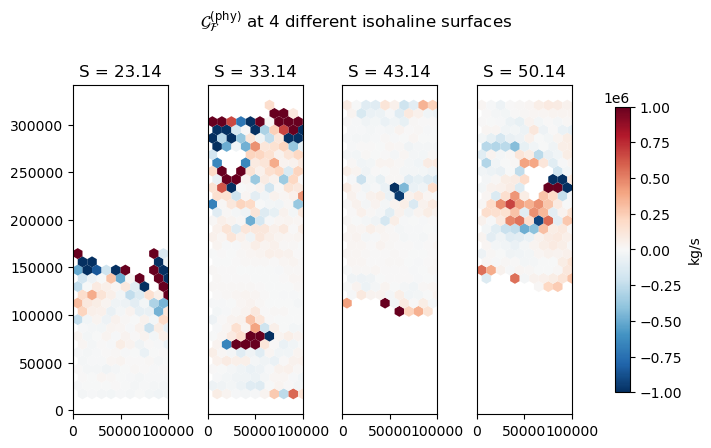

In [45]:
G_phy_plot = G_phy_ds.G_F_phy.isel(Time = time_idx)

fig,ax = plt.subplots(nrows=1,ncols=4,constrained_layout=True,figsize=(7,12))

mosaic.polypcolor(ax[0],descriptor, G_phy_plot.isel(salinity_P1=10),cmap='RdBu_r',vmin=-1e6,vmax=1e6)
mosaic.polypcolor(ax[1],descriptor, G_phy_plot.isel(salinity_P1=20),cmap='RdBu_r',vmin=-1e6,vmax=1e6)
mosaic.polypcolor(ax[2],descriptor, G_phy_plot.isel(salinity_P1=30),cmap='RdBu_r',vmin=-1e6,vmax=1e6)
c = mosaic.polypcolor(ax[3],descriptor, G_phy_plot.isel(salinity_P1=37),cmap='RdBu_r',vmin=-1e6,vmax=1e6)

surfaces = [10, 20, 30, 37]
for i in range(0,4):
    ax[i].set_aspect(1.0)
    ax[i].set_title(f'S = {np.round(G_phy_plot.salinity_P1[surfaces[i]].values,decimals=2)}')

for i in range(1,4):
    ax[i].set_ylabel('')
    ax[i].set_yticks([])
    
fig.colorbar(c, ax=ax[3],label='kg/s')
fig.suptitle(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$ at 4 different isohaline surfaces',y=0.7)

## Calculate $\mathcal{G}_\chi^{\text{(phy)}}$ from tracer variance decay

To compare physical mixing calculations, we plug in $\chi^{\text{(phy)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}_\chi^{\text{(phy)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(phy)}} \, \text{d}V\right] \tag{8}
\end{equation}
$$

In [48]:
# chi_phy is on nVertLevelsP1, but we need to interpolate onto nVertLevels to multiply by dV
# can you just grid.interpolate and assume that this remap will preserve all values? Because now this is different from TracerVertMixTendency, which is on nVertLevels
# and we would want to maintain dV, since it is the same across the two methods...?
# interpolation preserves the global integral of the calculated mixing... but I feel like it's better to calculate the dV via interp instead? 
# and keep everything on nVertLevelsP1 instead?
# actually, I think that you have to interpolate to center in order for a conservative remap to work (according to xgcm docs)

# ds_dvd.chiPhyVerSalt is on nVertLevelsP1, but we need for the datavariable to be on cell centers first
chi_interp = grid_nVertLevels.interp(ds_dvd.chiPhyVerSalt, axis='Z')
integrand_chi = rho_0 * chi_interp * dV

# we already have our target coordinates set up from calculating G_phy from conv of a diff flux, so we just need to do a conservative transform
ds_dvd_salinity_chiZ_transformed = grid_nVertLevels.transform(integrand_chi, # currently sitting on cell centers
                                                  'Z',
                                                  target_coords_P1,
                                                  method='conservative',
                                                  target_data = ds_output.salinity_P1)

ds_dvd_salinity_chiZ_transformed_ds = ds_dvd_salinity_chiZ_transformed.to_dataset(name='integrand_chi_transformed')

# the transform remapped the datavariable to the CENTER of the cell 
# rename the salinity_P1 coords to salinity
ds_dvd_salinity_chiZ_transformed_ds = ds_dvd_salinity_chiZ_transformed_ds.rename({'salinity_P1' : 'salinity'})

In [49]:
# calculate the first derivative
tendency = []

# take the first derivative (from salinty coords to salinity_P1 coords)
for i in range(0,len(target_coords_P1)-2):
    d_tracerMassFlux = ds_dvd_salinity_chiZ_transformed[:,:,i] - ds_dvd_salinity_chiZ_transformed[:,:,i+1]
    d_tracerMassFlux_dlambda = d_tracerMassFlux / dlambda
    tendency.append(d_tracerMassFlux_dlambda)

# convert tendency to dataset
tendency_da = xr.concat(tendency, dim='salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)

# take the second derivative (from salinity_P1 coords back to salinity coords)
# again, by taking the difference you will lose the first and last entries of the salinity coords
G_phy_chi = []

for i in range(0,len(target_coords)-2):
    d_tendency = tendency_da[i,:,:] - tendency_da[i+1,:,:]
    dtendency_dlambda = d_tendency / dlambda
    G_phy_chi.append(dtendency_dlambda * -0.5) # by definition, G_phy_chi is multiplied by -1/2

salinity_trimmed = target_coords[1:-1]
G_phy_chi_ds = (xr.concat(G_phy_chi, dim = 'salinity').assign_coords(salinity = salinity_trimmed)).to_dataset(name = 'G_chi_phy')

# add back the salinity_P1 coordinates
G_phy_chi_ds = G_phy_chi_ds.assign_coords({'salinity_P1' : salinity_P1_trimmed})

## Tentative $\mathcal{G}^{\text{(phy)}}_\chi$ plots 

In [50]:
# cumsum from bottom (lowest salinity class) to top (highest salinity class)
# we need to perform a reverse cumsum because our water mass M is defined to be all values GREATER Than threshold lambda
G_phy_chi = G_phy_chi_ds.G_chi_phy.isel(Time=time_idx).sum(dim='nCells')

rev_G_phy_chi = np.flipud(G_phy_chi)
cumsum_rev_G_phy_chi = np.cumsum(rev_G_phy_chi)
# reverse back to match highest salinity value to lowest cumsum value
cumsum_G_phy_chi = np.flipud(cumsum_rev_G_phy_chi)

Text(0.5, 0.98, 'Diascalar material transformation  $\\mathcal{G}_\\chi^{\\text{(phy)}}$ time_idx = 250')

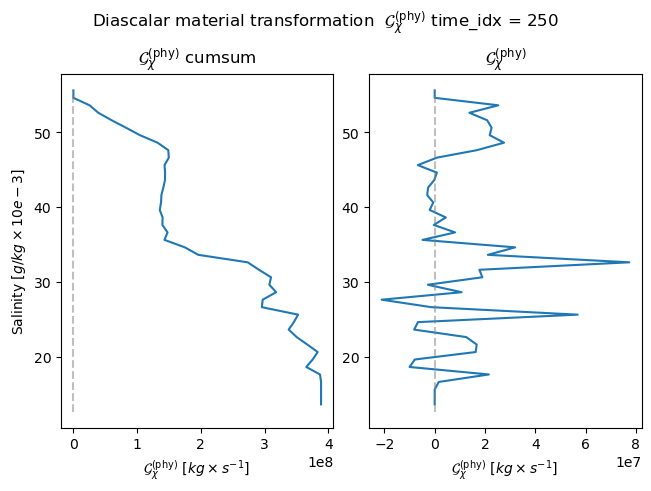

In [51]:
fig, ax = plt.subplots(nrows=1,ncols=2,constrained_layout=True)

ax[0].plot(cumsum_G_phy_chi, G_phy_chi_ds.salinity)
ax[0].set_title(r'$\mathcal{G}_\chi^{\text{(phy)}}$ cumsum')
ax[1].plot(G_phy_chi, G_phy_chi_ds.salinity)
ax[1].set_title(r'$\mathcal{G}_\chi^{\text{(phy)}}$')
ax[0].vlines(0,ymin=target_coords[0], ymax = G_phy_chi_ds.salinity[-1], color='gray', alpha=0.5,linestyle='dashed')
ax[1].vlines(0,ymin=target_coords[0], ymax = G_phy_chi_ds.salinity[-1], color='gray', alpha=0.5,linestyle='dashed')

ax[0].set_xlabel(r'$\mathcal{G}_\chi^{\text{(phy)}} \,\, \left[kg \times s^{-1}\right]$ ')
ax[0].set_ylabel(r'Salinity $\left[ g/kg \times 10e-3\right]$')

ax[1].set_xlabel(r'$\mathcal{G}_\chi^{\text{(phy)}} \,\, \left[kg \times s^{-1}\right]$ ')

fig.suptitle(r'Diascalar material transformation  $\mathcal{G}_\chi^{\text{(phy)}}$ time_idx = 250')

In [52]:
# average over time
# cumsum from bottom (lowest salinity class) to top (highest salinity class)
# we need to perform a reverse cumsum because our water mass M is defined to be all values GREATER Than threshold lambda
# reduce G_phy_ds along several dimensions
G_phy_chi = G_phy_chi_ds.G_chi_phy.mean(dim='Time').sum(dim = 'nCells')

rev_G_phy_chi = np.flipud(G_phy_chi)
cumsum_rev_G_phy_chi = np.cumsum(rev_G_phy_chi)
# reverse back to match highest salinity value to lowest cumsum value
cumsum_G_phy_chi = np.flipud(cumsum_rev_G_phy_chi)

## $\mathcal{G}_\chi^{\text{(phy)}}$ calculated from tracer variance decay

To make a plan view plot of at different isosurfaces, preserve `nCells` when calculating the tracerMassFlux derivative. 

Put the derivative onto salinity coords (since we're differencing, move from edge to center)

Text(0.5, 0.98, 'Time-Averaged Diascalar material transformation  $\\mathcal{G}_\\chi{F}^{\\text{(phy)}}$')

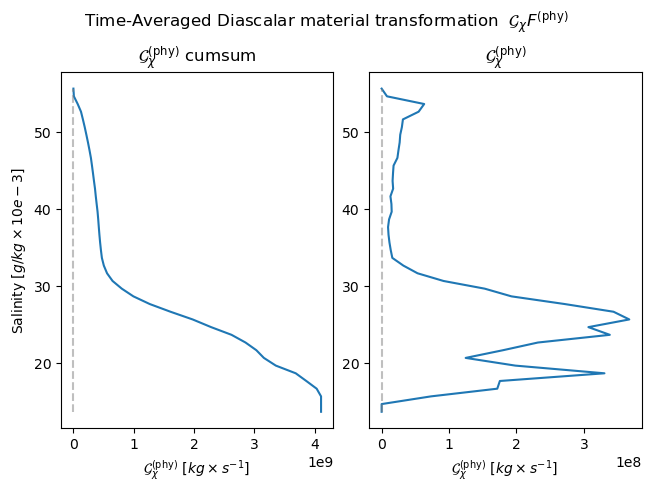

In [53]:
fig, ax = plt.subplots(nrows=1,ncols=2,constrained_layout=True)

ax[0].plot(cumsum_G_phy_chi, G_phy_chi_ds.salinity)
ax[0].set_title(r'$\mathcal{G}_\chi^{\text{(phy)}}$ cumsum')
ax[1].plot(G_phy_chi, G_phy_chi_ds.salinity)
ax[1].set_title(r'$\mathcal{G}_\chi^{\text{(phy)}}$')
ax[0].vlines(0,ymin=G_phy_chi_ds.salinity[0], ymax = G_phy_chi_ds.salinity[-1], color='gray', alpha=0.5,linestyle='dashed')
ax[1].vlines(0,ymin=G_phy_chi_ds.salinity[0], ymax = G_phy_chi_ds.salinity[-1], color='gray', alpha=0.5,linestyle='dashed')

ax[0].set_xlabel(r'$\mathcal{G}_\chi^{\text{(phy)}} \,\, \left[kg \times s^{-1}\right]$ ')
ax[0].set_ylabel(r'Salinity $\left[ g/kg \times 10e-3\right]$')

ax[1].set_xlabel(r'$\mathcal{G}_\chi^{\text{(phy)}} \,\, \left[kg \times s^{-1}\right]$ ')

fig.suptitle(r'Time-Averaged Diascalar material transformation  $\mathcal{G}_\chi{F}^{\text{(phy)}}$')

Text(0.5, 0.7, '$\\mathcal{G}_\\chi^{\\text{(phy)}}$ at 4 different isohaline surfaces')

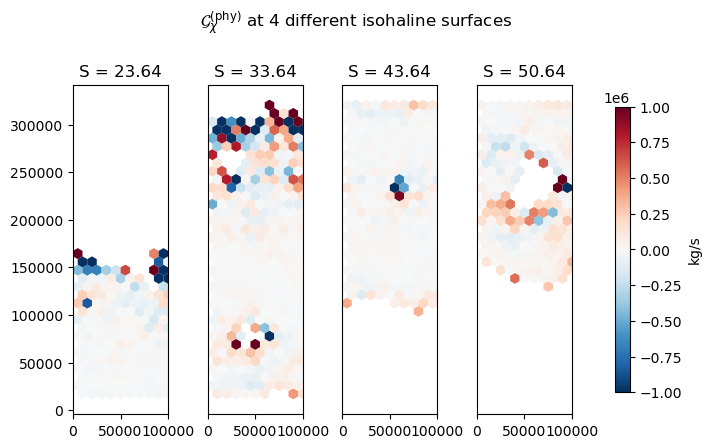

In [55]:
G_phy_chi_plot = G_phy_chi_ds.G_chi_phy.isel(Time = time_idx)

fig,ax = plt.subplots(nrows=1,ncols=4,constrained_layout=True,figsize=(7,12))

mosaic.polypcolor(ax[0],descriptor, G_phy_chi_plot.isel(salinity=10),cmap='RdBu_r',vmin=-1e6,vmax=1e6)
mosaic.polypcolor(ax[1],descriptor, G_phy_chi_plot.isel(salinity=20),cmap='RdBu_r',vmin=-1e6,vmax=1e6)
mosaic.polypcolor(ax[2],descriptor, G_phy_chi_plot.isel(salinity=30),cmap='RdBu_r',vmin=-1e6,vmax=1e6)
c = mosaic.polypcolor(ax[3],descriptor, G_phy_chi_plot.isel(salinity=37),cmap='RdBu_r',vmin=-1e6,vmax=1e6)

for i in range(0,4):
    ax[i].set_aspect(1.0)
    ax[i].set_title(f'S = {np.round(G_phy_chi_plot.salinity[surfaces[i]].values,decimals=2)}')

for i in range(1,4):
    ax[i].set_ylabel('')
    ax[i].set_yticks([])
    
fig.colorbar(c, ax=ax[3],label='kg/s')
fig.suptitle(r'$\mathcal{G}_\chi^{\text{(phy)}}$ at 4 different isohaline surfaces',y=0.7)

6/26/26 
>- At least the plots look somewhat alike? But the spatially summed plots (plan view) differ by about an order of magnitude :/
>- Also need to remap to compare. $\mathcal{G}_\mathcal{F}^\text{(phy)}$ is on `salinity_P1` but $\mathcal{G}_\chi^{\text{(phy)}}$ is on `salinity` coords
>- At first pass, the plan view plots look spatially somewhat correct?

## Comparison of calculations $\mathcal{G}^{\text{(phy)}}_\mathcal{F}$ vs $\mathcal{G}^{\text{(phy)}}_\chi$

### comparison of time-averaged diascalar material transformation

In [65]:
# combine the G_phy_ds and G_phy_chi_ds datasets
G_phy_comp_ds = xr.merge([G_phy_ds.G_F_phy.transpose('salinity_P1', 'nCells', 'Time'), G_phy_chi_ds])

In [66]:
G_phy_comp_ds

<xarray.Dataset> Size: 181MB
Dimensions:      (salinity_P1: 44, nCells: 360, Time: 721, salinity: 43)
Coordinates:
  * salinity_P1  (salinity_P1) float64 352B 13.14 14.14 15.14 ... 55.14 56.14
  * salinity     (salinity) float64 344B 13.64 14.64 15.64 ... 53.64 54.64 55.64
Dimensions without coordinates: nCells, Time
Data variables:
    G_F_phy      (salinity_P1, nCells, Time) float64 91MB nan nan ... nan nan
    G_chi_phy    (salinity, nCells, Time) float64 89MB nan nan nan ... nan nan

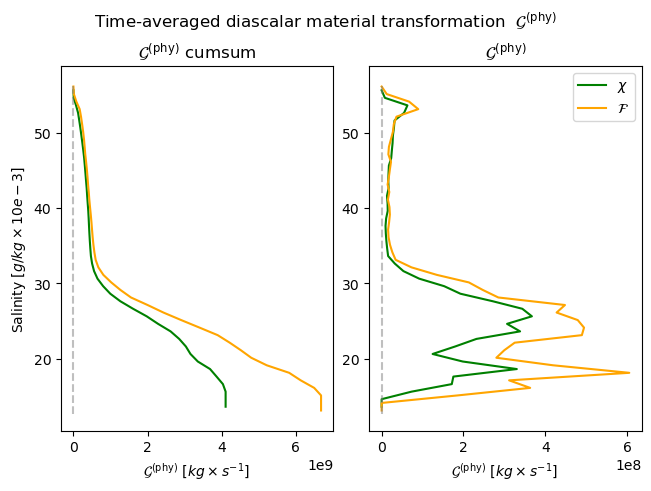

In [58]:
fig,ax = plt.subplots(nrows=1, ncols=2, constrained_layout=True)
ax[0].plot(cumsum_G_phy_chi, G_phy_comp_ds.salinity,color='green')
ax[0].plot(cumsum_G_phy, G_phy_comp_ds.salinity_P1,color='orange')
ax[0].set_title(r'$\mathcal{G}^{\text{(phy)}}$ cumsum')
ax[1].plot(G_phy_chi, G_phy_comp_ds.salinity,color='green',label=r'$\chi$')
ax[1].plot(G_phy, G_phy_comp_ds.salinity_P1,color='orange',label=r'$\mathcal{F}$')
ax[1].set_title(r'$\mathcal{G}^{\text{(phy)}}$')
ax[0].vlines(0,ymin=target_coords[0], ymax = target_coords[-1], color='gray', alpha=0.5,linestyle='dashed')
ax[1].vlines(0,ymin=target_coords[0], ymax = target_coords[-1], color='gray', alpha=0.5,linestyle='dashed')

ax[0].set_xlabel(r'$\mathcal{G}^{\text{(phy)}} \,\, \left[kg \times s^{-1}\right]$ ')
ax[0].set_ylabel(r'Salinity $\left[ g/kg \times 10e-3\right]$')

ax[1].set_xlabel(r'$\mathcal{G}^{\text{(phy)}} \,\, \left[kg \times s^{-1}\right]$ ')

fig.suptitle(r'Time-averaged diascalar material transformation  $\mathcal{G}^{\text{(phy)}}$')
ax[1].legend()

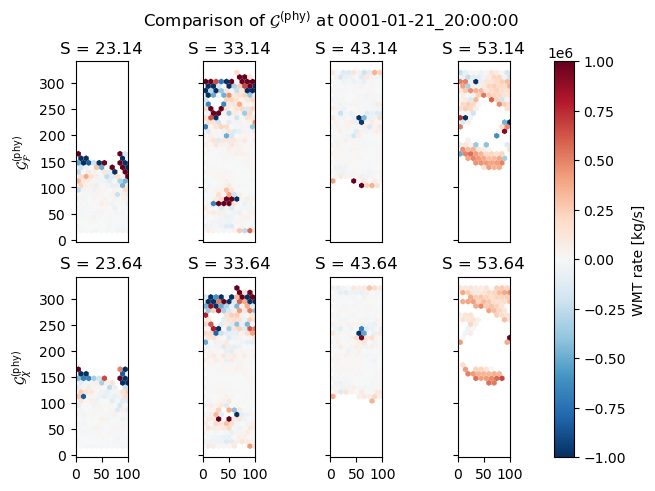

In [59]:
fig,ax = plt.subplots(nrows=2, ncols=4, constrained_layout=True)

G_phy_comp_ds_plot = G_phy_comp_ds.isel(Time = time_idx)
surfaces = np.array([10, 20, 30, 40])

# G_phy
mosaic.polypcolor(ax[0,0], descriptor, G_phy_comp_ds_plot.G_F_phy.isel(salinity_P1 = 10), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[0,1], descriptor, G_phy_comp_ds_plot.G_F_phy.isel(salinity_P1 = 20), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[0,2], descriptor, G_phy_comp_ds_plot.G_F_phy.isel(salinity_P1 = 30), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[0,3], descriptor, G_phy_comp_ds_plot.G_F_phy.isel(salinity_P1 = 40), cmap='RdBu_r', vmin=-1e6, vmax=1e6)

# G_phy_chi
mosaic.polypcolor(ax[1,0], descriptor, G_phy_comp_ds_plot.G_chi_phy.isel(salinity = 10), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[1,1], descriptor, G_phy_comp_ds_plot.G_chi_phy.isel(salinity = 20), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[1,2], descriptor, G_phy_comp_ds_plot.G_chi_phy.isel(salinity = 30), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
c = mosaic.polypcolor(ax[1,3], descriptor, G_phy_comp_ds_plot.G_chi_phy.isel(salinity = 40), cmap='RdBu_r', vmin=-1e6, vmax=1e6)

for i in range(0,2):
    for j in range(0,4):
        ax[i,j].set_yticklabels([])
        ax[i,j].set_xticks([])
        ax[i,j].set_aspect(1.0)
        ax[0,j].set_title(f'S = {np.round(G_phy_comp_ds_plot.salinity_P1[surfaces[j]].values,decimals=2)}')
        ax[1,j].set_title(f'S = {np.round(G_phy_comp_ds_plot.salinity[surfaces[j]].values,decimals=2)}')
        ax[1,j].set_xticks(np.arange(0,150000,50000))
        ax[1,j].set_xticklabels(np.arange(0,150,50).astype(str))

ax[0,0].set_yticks(np.arange(0,350000,50000))
ax[0,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[0,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')

ax[1,0].set_yticks(np.arange(0,350000,50000))
ax[1,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[1,0].set_ylabel(r'$\mathcal{G}_\chi^{\text{(phy)}}$')

fig.colorbar(c, ax = ax, label='WMT rate [kg/s]')
fig.suptitle(r'Comparison of $\mathcal{G}^{\text{(phy)}}$ at '+ str(ds_output.xtime.isel(Time=time_idx).values.item().decode('utf-8')));

In [60]:
# remap to get onto matching salinity coordinates
# make a grid that identifies salinity as the vertical coordinates
grid_salinity = Grid(G_phy_comp_ds, coords={'Z': {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                    periodic = False,
                    autoparse_metadata = False)

G_phy_comp_ds['G_F_phy_center'] = grid_salinity.interp(G_phy_comp_ds.G_F_phy, 'Z', boundary='extend')

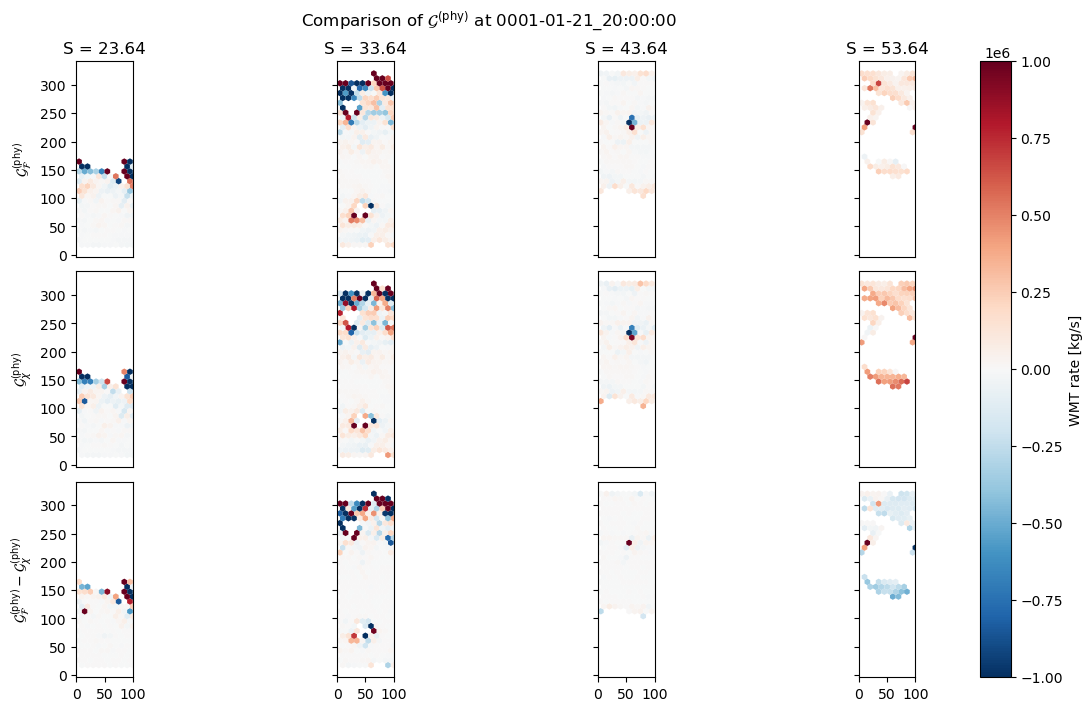

In [62]:
fig,ax = plt.subplots(nrows=3, ncols=4, constrained_layout=True, figsize=(12,7))

G_phy_comp_ds_plot = G_phy_comp_ds.isel(Time = time_idx)
diff = G_phy_comp_ds_plot.G_F_phy_center - G_phy_comp_ds_plot.G_chi_phy
surfaces = np.array([10, 20, 30, 40])

# G_phy
mosaic.polypcolor(ax[0,0], descriptor, G_phy_comp_ds_plot.G_F_phy_center.isel(salinity = 10), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[0,1], descriptor, G_phy_comp_ds_plot.G_F_phy_center.isel(salinity = 20), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[0,2], descriptor, G_phy_comp_ds_plot.G_F_phy_center.isel(salinity = 30), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[0,3], descriptor, G_phy_comp_ds_plot.G_F_phy_center.isel(salinity = 40), cmap='RdBu_r', vmin=-1e6, vmax=1e6)

# G_phy_chi
mosaic.polypcolor(ax[1,0], descriptor, G_phy_comp_ds_plot.G_chi_phy.isel(salinity = 10), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[1,1], descriptor, G_phy_comp_ds_plot.G_chi_phy.isel(salinity = 20), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[1,2], descriptor, G_phy_comp_ds_plot.G_chi_phy.isel(salinity = 30), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
c = mosaic.polypcolor(ax[1,3], descriptor, G_phy_comp_ds_plot.G_chi_phy.isel(salinity = 40), cmap='RdBu_r', vmin=-1e6, vmax=1e6)

# diff G_phy - G_phy_chi
mosaic.polypcolor(ax[2,0], descriptor, diff.isel(salinity = 10), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[2,1], descriptor, diff.isel(salinity = 20), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[2,2], descriptor, diff.isel(salinity = 30), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[2,3], descriptor, diff.isel(salinity = 40), cmap='RdBu_r', vmin=-1e6, vmax=1e6)

for i in range(0,3):
    for j in range(0,4):
        ax[i,j].set_yticklabels([])
        ax[i,j].set_xticks([])
        ax[i,j].set_aspect(1.0)
        ax[0,j].set_title(f'S = {np.round(G_phy_comp_ds_plot.salinity[surfaces[j]].values,decimals=2)}')
        ax[2,j].set_xticks(np.arange(0,150000,50000))
        ax[2,j].set_xticklabels(np.arange(0,150,50).astype(str))

ax[0,0].set_yticks(np.arange(0,350000,50000))
ax[0,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[0,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')

ax[1,0].set_yticks(np.arange(0,350000,50000))
ax[1,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[1,0].set_ylabel(r'$\mathcal{G}_\chi^{\text{(phy)}}$')

ax[2,0].set_yticks(np.arange(0,350000,50000))
ax[2,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[2,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}} - \mathcal{G}_\chi^{\text{(phy)}}$')

fig.colorbar(c, ax = ax, label='WMT rate [kg/s]')
fig.suptitle(r'Comparison of $\mathcal{G}^{\text{(phy)}}$ at '+ str(ds_output.xtime.isel(Time=time_idx).values.item().decode('utf-8')));

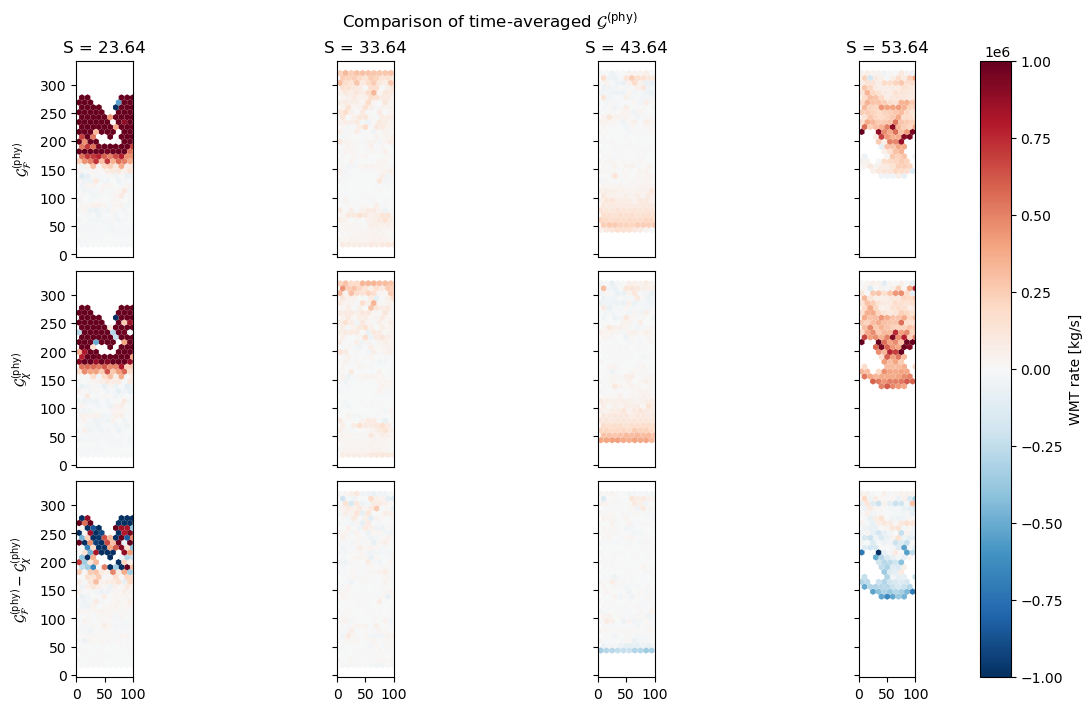

In [63]:
fig,ax = plt.subplots(nrows=3, ncols=4, constrained_layout=True, figsize=(12,7))

G_phy_comp_ds_plot = G_phy_comp_ds.mean(dim='Time')
diff = G_phy_comp_ds_plot.G_F_phy_center - G_phy_comp_ds_plot.G_chi_phy
surfaces = np.array([10, 20, 30, 40])

# G_phy
mosaic.polypcolor(ax[0,0], descriptor, G_phy_comp_ds_plot.G_F_phy_center.isel(salinity = 10), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[0,1], descriptor, G_phy_comp_ds_plot.G_F_phy_center.isel(salinity = 20), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[0,2], descriptor, G_phy_comp_ds_plot.G_F_phy_center.isel(salinity = 30), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[0,3], descriptor, G_phy_comp_ds_plot.G_F_phy_center.isel(salinity = 40), cmap='RdBu_r', vmin=-1e6, vmax=1e6)

# G_phy_chi
mosaic.polypcolor(ax[1,0], descriptor, G_phy_comp_ds_plot.G_chi_phy.isel(salinity = 10), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[1,1], descriptor, G_phy_comp_ds_plot.G_chi_phy.isel(salinity = 20), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[1,2], descriptor, G_phy_comp_ds_plot.G_chi_phy.isel(salinity = 30), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
c = mosaic.polypcolor(ax[1,3], descriptor, G_phy_comp_ds_plot.G_chi_phy.isel(salinity = 40), cmap='RdBu_r', vmin=-1e6, vmax=1e6)

# diff G_phy - G_phy_chi
mosaic.polypcolor(ax[2,0], descriptor, diff.isel(salinity = 10), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[2,1], descriptor, diff.isel(salinity = 20), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[2,2], descriptor, diff.isel(salinity = 30), cmap='RdBu_r', vmin=-1e6, vmax=1e6)
mosaic.polypcolor(ax[2,3], descriptor, diff.isel(salinity = 40), cmap='RdBu_r', vmin=-1e6, vmax=1e6)

for i in range(0,3):
    for j in range(0,4):
        ax[i,j].set_yticklabels([])
        ax[i,j].set_xticks([])
        ax[i,j].set_aspect(1.0)
        ax[0,j].set_title(f'S = {np.round(G_phy_comp_ds_plot.salinity[surfaces[j]].values,decimals=2)}')
        ax[2,j].set_xticks(np.arange(0,150000,50000))
        ax[2,j].set_xticklabels(np.arange(0,150,50).astype(str))

ax[0,0].set_yticks(np.arange(0,350000,50000))
ax[0,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[0,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')

ax[1,0].set_yticks(np.arange(0,350000,50000))
ax[1,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[1,0].set_ylabel(r'$\mathcal{G}_\chi^{\text{(phy)}}$')

ax[2,0].set_yticks(np.arange(0,350000,50000))
ax[2,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[2,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}} - \mathcal{G}_\chi^{\text{(phy)}}$')

fig.colorbar(c, ax = ax, label='WMT rate [kg/s]')
fig.suptitle(r'Comparison of time-averaged $\mathcal{G}^{\text{(phy)}}$');